## ТЕОРИЯ ВЕРОЯТНОСТЕЙ
***
Подготовлено: Жуликовой Анастасией, гр. 543

In [42]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np

%matplotlib inline

### ТЕМА 1. МОДЕЛИРОВАНИЕ ГЕОМЕТРИЧЕСКОЙ ВЕРОЯТНОСТИ
***
> <b>Задание</b>: Смоделируйте вычисление геометрической вероятности. Показать теоретический расчёт и графическую иллюстрацию для рассматриваемого примера.

<b>Решение</b>.
Приведу пример задачи:
> Стрелок целится в стену площадью S, перед которой стоит мальчик с яблоком на голове. Известно, что площадь, которую занимает голова мальчика, составляет 10% от площади стены. При этом яблоко на его голове ровно в два раза меньше площади головы. Какова вероятность того, что стрелок попадет в яблоко?

In [165]:
def hitting_in_apple(n):
    R_head = 5
    percent = 10
    fig, ax = plt.subplots(figsize = (6, 6))
    ax.set_aspect('equal')
    
    #Площадь головы
    S_head = np.pi * R_head**2
    #Площадь яблока в два раза меньше площади головы
    S_apple = S_head / 2
    R_apple = np.sqrt(S_apple / np.pi)
    #Площадь стены в percent раз больше яблока
    S_wall = S_head * (100 / percent)
    len_wall = np.sqrt(S_wall)
    
    ax.set_xlim(0, len_wall)
    ax.set_ylim(0, len_wall)
    
    #Рисуем фон
    ax.add_patch(Rectangle((0, 0), len_wall, len_wall, color="lavender"))
    ax.grid(alpha=0.2)
    
    #Рисуем яблоко
    weight = 0 #Чтобы в случае увеличения процента можно увеличить weight и увидеть всю картинку
    x_apple = (len_wall / 2)
    y_apple = (len_wall / 2) + weight
    ax.add_patch(Circle((x_apple, y_apple), R_apple, facecolor="lightgreen", edgecolor="darkgreen", linewidth=2))
    ax.plot([x_apple, x_apple], [y_apple+R_apple, y_apple+1.5*R_apple], color="darkgreen", linewidth=2)
    
    #Рисуем голову
    ax.add_patch(Circle((x_apple, y_apple-R_apple-R_head), R_head, facecolor="lightyellow", edgecolor="brown", linewidth=2))
    #Левый глаз
    ax.add_patch(Circle((0.8*x_apple, y_apple-R_apple-R_head), 0.3*R_head, facecolor="white", edgecolor="black", linewidth=2))
    ax.add_patch(Circle((0.83*x_apple, y_apple-R_apple-R_head), 0.2*R_head, facecolor="black", edgecolor="black", linewidth=2))
    #Правый глаз
    ax.add_patch(Circle((1.2*x_apple, y_apple-R_apple-R_head), 0.3*R_head, facecolor="white", edgecolor="black", linewidth=2))
    ax.add_patch(Circle((1.17*x_apple, y_apple-R_apple-R_head), 0.2*R_head, facecolor="black", edgecolor="black", linewidth=2))
    
    #Помечаем крестиком случайное попадание стрелка
    mn = 0
    mx = len_wall
    X = mn + np.random.random(n) * (mx-mn)
    Y = mn + np.random.random(n) * (mx-mn)
    ax.scatter(X, Y, marker="x", color="red")
    
    #Выстрелы, которые попали в яблоко
    inside = len([d for d in (X-x_apple)**2 + (Y-y_apple)**2 if d <= R**2])
    #Вероятность попадания в яблоко
    prob = inside / n
    
    print(f"Из {n} выстрелов в яблоко попало {inside} выстрелов. Доля попавших выстрелов = {prob}")

Из 100 выстрелов в яблоко попало 11 выстрелов. Доля попавших выстрелов = 0.11


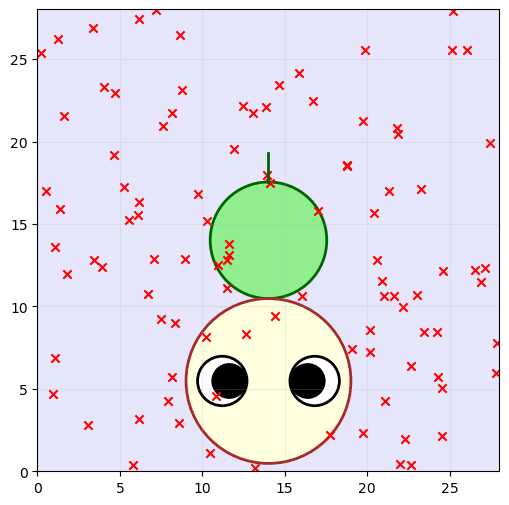

In [172]:
hitting_in_apple(100)